<a href="https://colab.research.google.com/github/Ijo2004/Crushathon/blob/main/Expml1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Gradient Descent Converged
Epochs = 1731
alpha0 = 1.6545744208140671
alpha1 = 0.07678469191735464

Normal Equation
alpha0 = 1.6547622685968426
alpha1 = 0.07675558963126718

Performance Comparison
-------------------------
Gradient Descent
SSE = 5334.7839359415475
R2 Score = 0.013787991983901238

Normal Equation
SSE = 5334.744201165253
R2 Score = 0.013795337532284901


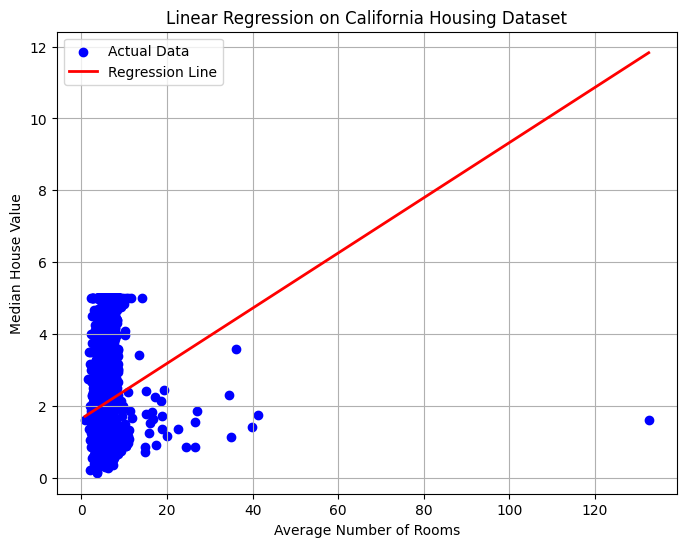

In [1]:

# Linear Regression using Gradient Descent and Normal Equation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load the California Housing Dataset
housing = fetch_california_housing()

# Select the feature (Average Number of Rooms)
X = housing.data[:, 2].reshape(-1, 1)

# Target variable
y = housing.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Gradient Descent
m, alpha0, alpha1, eta, tolerance, previous_sse, epoch = len(X_train), 0.0, 0.0, 1e-6, 1e-6, float("inf"), 0

while True:
    y_pred_train = alpha0 + alpha1 * X_train.flatten()
    error = y_pred_train - y_train
    current_sse = np.sum(error ** 2)

    if abs(previous_sse - current_sse) < tolerance:
        break

    previous_sse = current_sse

    d_alpha0 = 2 * np.sum(error)
    d_alpha1 = 2 * np.sum(error * X_train.flatten())

    alpha0 = alpha0 - eta * d_alpha0
    alpha1 = alpha1 - eta * d_alpha1

    epoch += 1

print("\nGradient Descent Converged")
print("Epochs =", epoch)
print("alpha0 =", alpha0)
print("alpha1 =", alpha1)

# Prediction using Gradient Descent
y_pred_gd = alpha0 + alpha1 * X_test.flatten()

# Performance computation for Gradient Descent
sse_gd = np.sum((y_test - y_pred_gd) ** 2)
r2_gd = r2_score(y_test, y_pred_gd)

# Normal Equation
X_train_NE = np.c_[np.ones((len(X_train), 1)), X_train]
alpha = np.linalg.inv(X_train_NE.T @ X_train_NE) @ X_train_NE.T @ y_train
alpha0_NE = alpha[0]
alpha1_NE = alpha[1]

print("\nNormal Equation")
print("alpha0 =", alpha0_NE)
print("alpha1 =", alpha1_NE)

# Prediction using Normal Equation
X_test_NE = np.c_[np.ones((len(X_test), 1)), X_test]
y_pred_NE = X_test_NE @ alpha

# Performance computation for Normal Equation
sse_NE = np.sum((y_test - y_pred_NE) ** 2)
r2_NE = r2_score(y_test, y_pred_NE)

# Display Results
print("\nPerformance Comparison")
print("-" * 25)
print("Gradient Descent")
print("SSE =", sse_gd)
print("R2 Score =", r2_gd)

print("\nNormal Equation")
print("SSE =", sse_NE)
print("R2 Score =", r2_NE)

# Plot Regression Line
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color="blue", label="Actual Data")
sorted_index = np.argsort(X_test.flatten())
plt.plot(X_test.flatten()[sorted_index], y_pred_NE[sorted_index], color="red", linewidth=2, label="Regression Line")
plt.xlabel("Average Number of Rooms")
plt.ylabel("Median House Value")
plt.title("Linear Regression on California Housing Dataset")
plt.legend()
plt.grid(True)
plt.show()